# Prerna Ladkani D16AD 37

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import tensorflow as tf

In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
from keras.optimizers import SGD, Adagrad, Adam

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
from keras.utils import normalize

x_train = normalize(x_train, axis=1)
x_test = normalize(x_test, axis=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_model(optimizer):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    model.add(Dense(128, activation=tf.nn.sigmoid))
    model.add(Dense(64, activation=tf.nn.sigmoid))
    model.add(Dense(10, activation=tf.nn.softmax))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Mini Batch SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9),
    'Nesterov': tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9, nesterov=True),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=0.01),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.01)
}

In [ ]:
histories = {}

for name, optimizer in optimizers.items():
    print(f"\nTraining with {name} optimizer:")
    model = build_model(optimizer)
    history = model.fit(x_train, to_categorical(y_train, num_classes=10), epochs=5)
    histories[name] = history.history['loss']


Training with SGD optimizer:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1240 - loss: 2.3048
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2372 - loss: 2.2582
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3864 - loss: 2.1805
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5434 - loss: 1.9843
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6325 - loss: 1.6138

Training with Mini Batch SGD optimizer:
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1272 - loss: 2.3078
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2336 - loss: 2.2576
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4601 - loss: 2.1806
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5906 - loss: 1.9816
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6597 - loss: 1.5694

Training with Momentum optimizer:
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step -

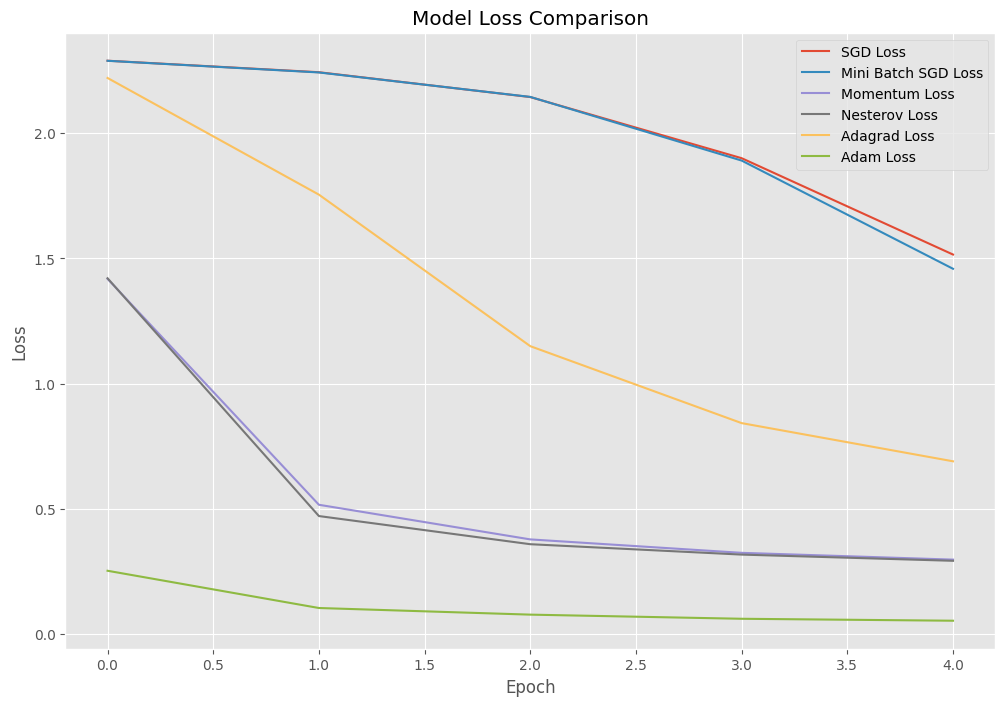

In [ ]:
plt.figure(figsize=(12, 8))

for name, loss in histories.items():
    plt.plot(loss, label=f'{name} Loss')

plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()